## РК2 по дисциплине "Технологии Машинного Обучения"
**Выполнила:** Канаева Диана Чингисовна

**Группа:** ИУ5-62Б

**Тема:** Методы построения моделей машинного обучения

**Задание:**
Для заданного набора данных постройте модели классификации или регрессии. Используйте:
1. Метод опорных векторов (SVM)
2. Случайный лес (Random Forest)

Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.

**Вопросы:** Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей?

**Датасет:** [Global Housing Market Analysis 2015-2024](https://www.kaggle.com/datasets/atharvasoundankar/global-housing-market-analysis-2015-2024)

### Решение
1. Загрузка данных и предварительный анализ

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Настройка отображения
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Загрузка данных
df = pd.read_csv('global_housing_market_extended.csv')
print("Размер датасета:", df.shape)
display(df.head())

Размер датасета: (200, 11)


,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


2. Предобработка данных

2.1. Обработка пропусков

In [18]:
# Проверка пропущенных значений
print("Пропущенные значения:")
print(df.isnull().sum())

# Заполнение числовых пропусков медианой
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Заполнение категориальных пропусков модой
categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Пропущенные значения:
Country                  0
Year                     0
House Price Index        0
Rent Index               0
Affordability Ratio      0
Mortgage Rate (%)        0
Inflation Rate (%)       0
GDP Growth (%)           0
Population Growth (%)    0
Urbanization Rate (%)    0
Construction Index       0
dtype: int64


2.2. Кодирование категориальных признаков

In [19]:
# Label Encoding для категориальных признаков
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

2.3. Визуализация данных

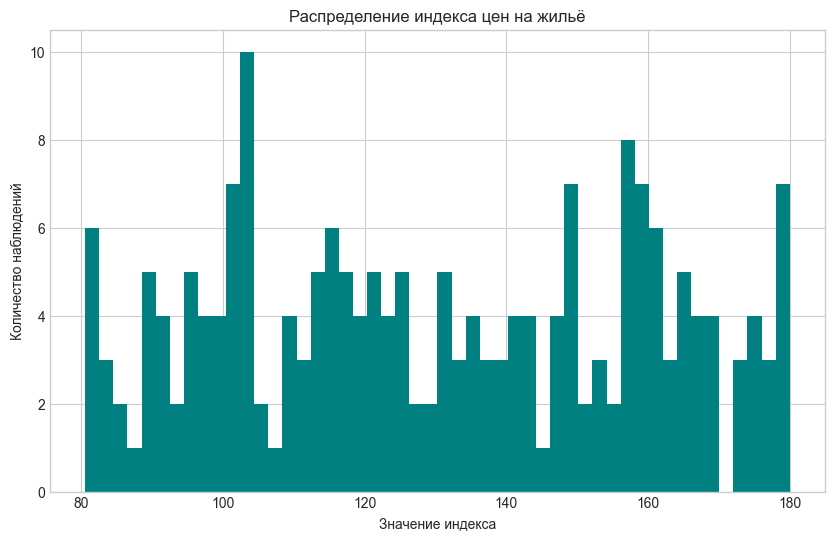

In [20]:
# Гистограмма распределения House Price Index
plt.figure(figsize=(10,6))
df['House Price Index'].hist(bins=50, color='teal')
plt.title('Распределение индекса цен на жильё')
plt.xlabel('Значение индекса')
plt.ylabel('Количество наблюдений')
plt.show()

3. Подготовка данных для моделирования

In [21]:
# Создание категориальной целевой переменной
df['Price_Category'] = pd.qcut(df['House Price Index'], q=4, labels=[0,1,2,3])

# Выбор признаков
features = ['Rent Index', 'Affordability Ratio', 'Mortgage Rate (%)', 
           'Inflation Rate (%)', 'GDP Growth (%)', 'Population Growth (%)']
X = df[features]
y = df['Price_Category']

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. Построение моделей

4.1. Метод опорных векторов (SVM)

In [22]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

# Оценка качества
print("SVM Metrics:")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred, average='weighted'))

SVM Metrics:
Accuracy: 0.25
F1 Score: 0.2497795434080195


4.2. Случайный лес (Random Forest)

In [23]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Оценка качества
print("\nRandom Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred, average='weighted'))


Random Forest Metrics:
Accuracy: 0.25
F1 Score: 0.2580519244734931


5. Анализ результатов

5.1. Сравнение метрик

In [24]:
metrics = pd.DataFrame({
    'Model': ['SVM', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, svm_pred), accuracy_score(y_test, rf_pred)],
    'F1 Score': [f1_score(y_test, svm_pred, average='weighted'), 
                f1_score(y_test, rf_pred, average='weighted')]
})
display(metrics)

,Model,Accuracy,F1 Score
0,SVM,0.25,0.249780
1,Random Forest,0.25,0.258052


5.2. Матрицы ошибок

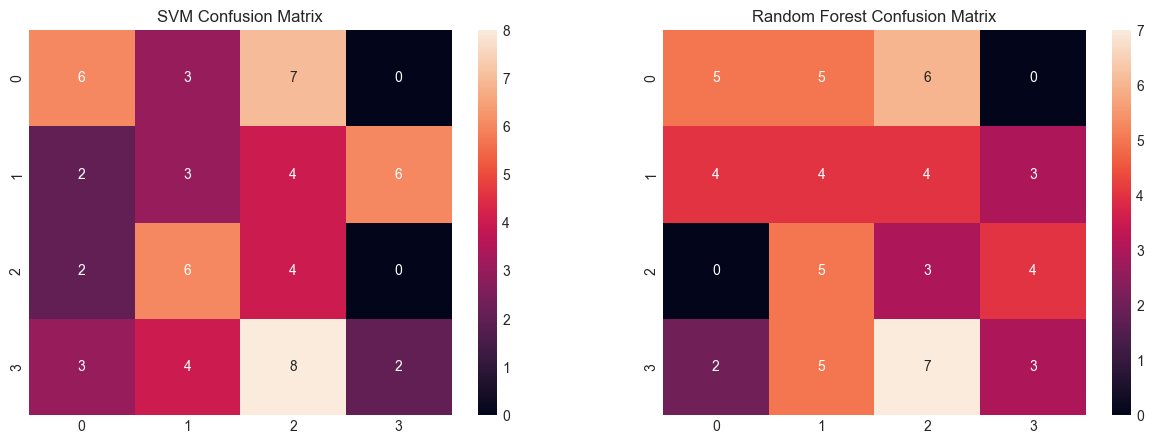

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', ax=ax[0])
ax[0].set_title('SVM Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
plt.show()

**Используемые метрики качества:**

Accuracy (Точность) - показывает долю правильных предсказаний от общего числа примеров. Использована потому, что это интуитивно понятная метрика для оценки общей правильности модели.

F1-score (F-мера) - гармоническое среднее точности и полноты. Использована потому, что она лучше учитывает дисбаланс классов, чем accuracy.

**Выводы:**

Модели не смогли научиться эффективным закономерностям в данных, F1 у Random Forest (0.258) немного лучше SVM (0.250), но разница минимальна.